In [2]:
from Common_domain import LightGlue,CustomSPNet
from utils import *
import viz2d
from pathlib import Path
import numpy as np

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 

extractor = CustomSPNet(max_num_keypoints=2048).eval().to(device) 
matcher = LightGlue(features="superpoint").eval().to(device)

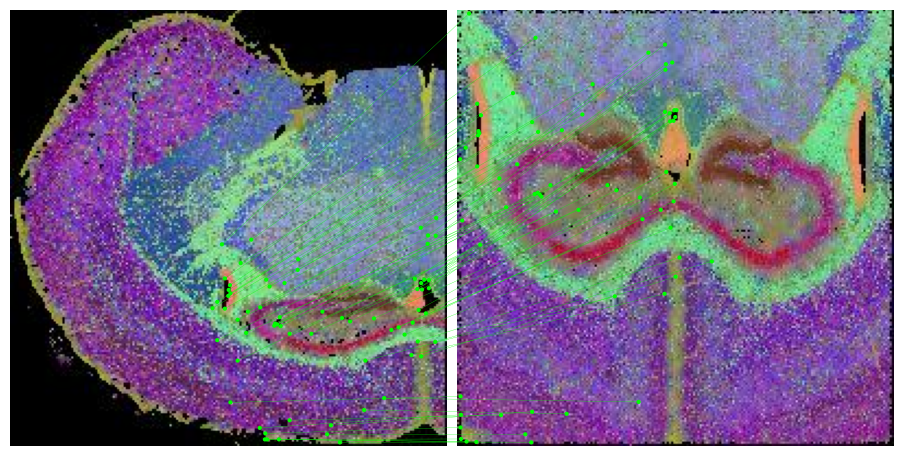

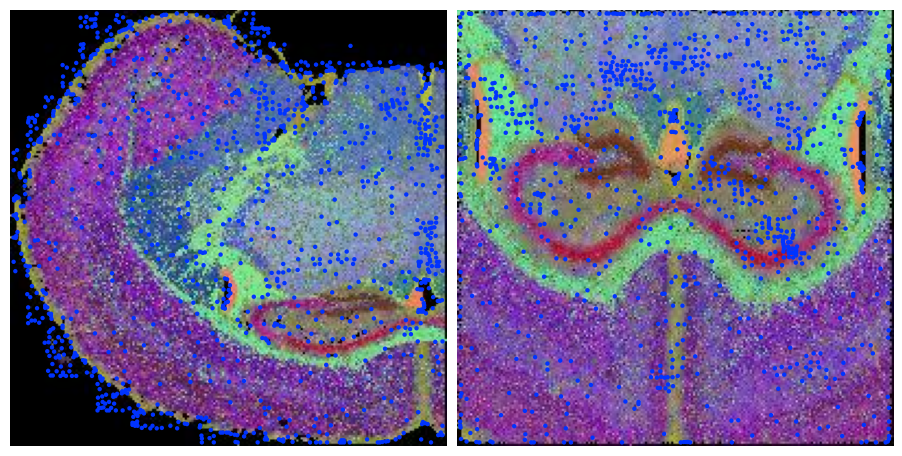

In [4]:
image0 = load_image("img_s1.JPG")
image1 = load_image("img_s3.JPG")

feats0 = extractor.extract(image0.to(device))
feats1 = extractor.extract(image1.to(device))

matches01 = matcher({"image0": feats0, "image1": feats1})
feats0, feats1, matches01 = [
    rbd(x) for x in [feats0, feats1, matches01]
]  # remove batch dimension

kpts0, kpts1, matches = feats0["keypoints"], feats1["keypoints"], matches01["matches"]
m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]]

axes = viz2d.plot_images([image0, image1])
viz2d.plot_matches(m_kpts0, m_kpts1, color="lime", lw=0.2)

kpc0, kpc1 = viz2d.cm_prune(matches01["prune0"]), viz2d.cm_prune(matches01["prune1"])
viz2d.plot_images([image0, image1])
viz2d.plot_keypoints([kpts0, kpts1], colors=[kpc0, kpc1], ps=10)

In [5]:
def plot_images(imgs, titles=None, cmaps="gray", dpi=100, pad=0.5, adaptive=True):
    imgs = [
        img.permute(1, 2, 0).cpu().numpy()
        if (isinstance(img, torch.Tensor) and img.dim() == 3)
        else img
        for img in imgs
    ]

    n = len(imgs)
    if not isinstance(cmaps, (list, tuple)):
        cmaps = [cmaps] * n

    if adaptive:
        ratios = [i.shape[1] / i.shape[0] for i in imgs]
    else:
        ratios = [4 / 3] * n
    figsize = [sum(ratios) * 4.5, 4.5]
    fig, ax = plt.subplots(
        1, n, figsize=figsize, dpi=dpi, gridspec_kw={"width_ratios": ratios}
    )
    if n == 1:
        ax = [ax]
    for i in range(n):
        ax[i].imshow(imgs[i], cmap=plt.get_cmap(cmaps[i]))
        ax[i].get_yaxis().set_ticks([])
        ax[i].get_xaxis().set_ticks([])
        ax[i].set_axis_off()
        for spine in ax[i].spines.values(): 
            spine.set_visible(False)
        if titles:
            ax[i].set_title(titles[i])
    fig.tight_layout(pad=pad)
    return ax 


def plot_rect(axes, xmin, xmax, ymin, ymax, color="red", lw=2):
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=lw, edgecolor=color, facecolor='none')
    axes.add_patch(rect)

In [8]:
m_kpts0_np = m_kpts0.cpu().numpy()
m_kpts1_np = m_kpts1.cpu().numpy()

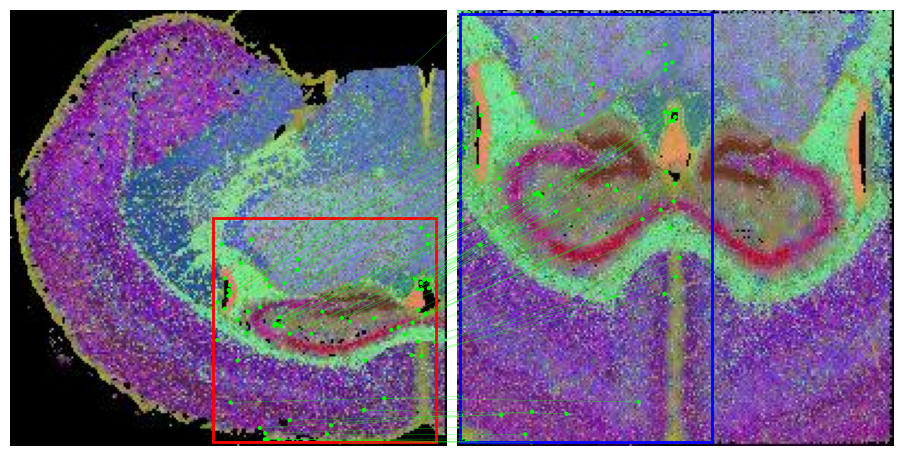

In [12]:
m_kpts0_np = m_kpts0.cpu().numpy()
x_min = m_kpts0_np[:, 0].min()
x_max = m_kpts0_np[:, 0].max()
y_min = m_kpts0_np[:, 1].min()
y_max = m_kpts0_np[:, 1].max()

region = (x_min.item(), x_max.item(), y_min.item(), y_max.item())

m_kpts1_np = m_kpts1.cpu().numpy()
x1_min = m_kpts1_np[:, 0].min()
x1_max = m_kpts1_np[:, 0].max()
y1_min = m_kpts1_np[:, 1].min()
y1_max = m_kpts1_np[:, 1].max()
region1 = (x1_min.item(), x1_max.item(), y1_min.item(), y1_max.item())


axes = plot_images([image0, image1])
viz2d.plot_matches(m_kpts0, m_kpts1, color="lime", lw=0.2)

plot_rect(axes[0], x_min, x_max, y_min, y_max, color="red", lw=2)
plot_rect(axes[1], x1_min, x1_max, y1_min, y1_max, color="blue", lw=2)

kpc0, kpc1 = viz2d.cm_prune(matches01["prune0"]), viz2d.cm_prune(matches01["prune1"])